In [4]:
import os
import sys

current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)
from src.models.filter_data.filter_data import *
from src.models.filter_data.feature_adder import *


In [5]:
temp_feature = "temperature"
csv_read_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")

df = pd.read_csv(csv_read_path, encoding='utf-8')

In [6]:
csv_read_path = os.path.join(project_root, "data", "interim", "factors.csv")
df_factors = pd.read_csv(csv_read_path)
coefs = get_coefs(df_factors)

In [18]:
from matplotlib import pyplot as plt


def plot_result_lines(x, y, a_s, b_s):
    plt.figure(figsize=(6, 5))
    plt.scatter(x, y, s=5, alpha=0.6, color='gray')

    xx = np.linspace(x.min(), x.max(), 300)

    cmap = plt.cm.tab10  # colormap با رنگ‌های متمایز
    
    a = a_s[0]
    b = b_s[0]
    i = 0
    yy = a * xx + b
    plt.plot(xx, yy, color=cmap(i % cmap.N), linewidth=2, label=f'spliter line')
    
    a = a_s[1]
    b = b_s[1]
    i = 1
    yy = a * xx + b
    plt.plot(xx, yy, color=cmap(i % cmap.N), linewidth=2, label=f'declared line', linestyle="--")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Unsupervised Maximum Gap Lines")
    plt.grid()
    plt.legend()
    plt.show()

شهدای پاکدشت - دماوند G13


<Figure size 600x500 with 0 Axes>

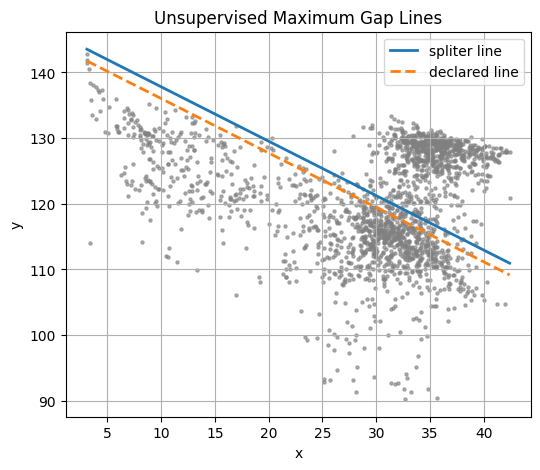

a = -0.830, b = 146.128


In [19]:
name_plot = "شهدای پاکدشت - دماوند"
code_plot = "G13"
power_plants = df[['name', 'code']].drop_duplicates()

print(name_plot,code_plot)
ds_n_c_plot = Data_selector(Data_selector(df).select_peaks(goodness=3,is_tight=False))
df_n_c = ds_n_c_plot.filter_name_code(name_plot, code_plot)
X = df_n_c["temperature"].values
y = df_n_c["generation"].values
mask = (X > 0) & ((y - (X * (-0.7) + 140)) > -30)
p_min = 0.8
p_max = 0.99
delta = 1
X = X[mask]
y = y[mask]
interval = (0,20)
a_u = coefs[(name_plot, code_plot)][0]
a, b = find_best_gap_line_given_slope(X, y, a_u, p_min, p_max, delta, interval)
plt.figure(figsize=(6, 5))

a_s = [a, coefs[(name_plot, code_plot)][0]]
b_s = [b, coefs[(name_plot, code_plot)][1]]

plot_result_lines(X, y, a_s, b_s)
plt.show()
print(f"a = {a:.3f}, b = {b:.3f}")